# DeepStock Research Framework

This notebook compares three approaches for stock price prediction:

- **ARIMA** (classical statistical baseline)
- **Dense (MLP)** (non-sequential neural baseline)
- **LSTM** (sequence-based deep model)

It uses `indexFinal_Clean.csv` as the dataset. Run this in a Python environment with the required packages installed (preferably Google Colab with GPU for LSTM training).

---


## 1) Setup & Imports

The cells below import required libraries. If you don't have some packages (tensorflow, statsmodels), run the install commands in the cell comments or use Colab.

In [ ]:
# Install notes (uncomment if needed in Colab)
# !pip install -q tensorflow statsmodels scikit-learn matplotlib seaborn nbformat

import warnings
warnings.filterwarnings('ignore')

import os, math, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set seeds
SEED = 42
random.seed(SEED); np.random.seed(SEED)
sns.set_style('whitegrid')

## 2) Load data

The notebook will try to detect a 'Date' column and a price column (Close, CloseUSD, etc.). Ensure `indexFinal_Clean.csv` is in the notebook folder or upload it to Colab `/content` or to `/mnt/data` here.

In [ ]:
csv_path = '/content/indexStock_Funal.csv'  # keep file in same folder or change this path
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"File not found: {csv_path}. Upload the CSV to the working directory.")

df = pd.read_csv(csv_path)
print('Loaded:', df.shape)
display(df.head())

# detect columns
date_col = next((c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()), None)
price_col_candidates = [c for c in df.columns if any(k in c.lower() for k in ['close','price','adj close'])]
price_col = price_col_candidates[0] if price_col_candidates else df.select_dtypes(include=[np.number]).columns[-1]
print('Detected date column:', date_col)
print('Detected price column:', price_col)

# basic cleaning
if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)

df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
df = df.dropna(subset=[price_col]).reset_index(drop=True)
print('After cleaning:', df.shape)

Loaded: (48256, 12)


,Index,Date,CloseUSD,Region,Exchange,Currency,Open,High,Low,Close,Adj Close,Volume
0,000001.SS,1997-07-02,191.849766,China,Shanghai Stock Exchange,CNY,1255.909058,1261.571045,1147.331055,1199.061035,1199.061035,0.0
1,000001.SS,1997-07-03,184.099688,China,Shanghai Stock Exchange,CNY,1194.676025,1194.676025,1149.939941,1150.623047,1150.623047,0.0
2,000001.SS,1997-07-04,185.494727,China,Shanghai Stock Exchange,CNY,1138.921021,1163.249023,1124.776001,1159.342041,1159.342041,0.0
3,000001.SS,1997-07-07,175.491035,China,Shanghai Stock Exchange,CNY,1161.707031,1163.447021,1085.572021,1096.818970,1096.818970,0.0
4,000001.SS,1997-07-08,177.546563,China,Shanghai Stock Exchange,CNY,1092.798950,1115.432983,1066.043945,1109.666016,1109.666016,0.0


Detected date column: Date
Detected price column: CloseUSD
After cleaning: (48256, 12)


## 3) Exploratory visualization

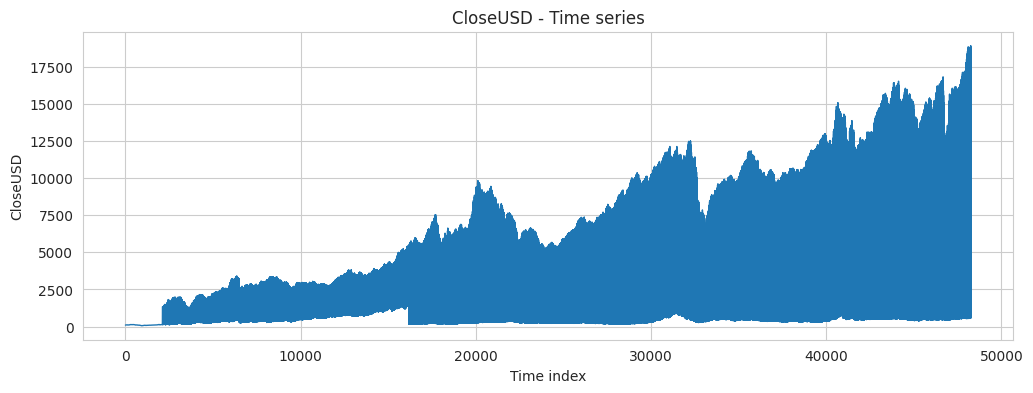

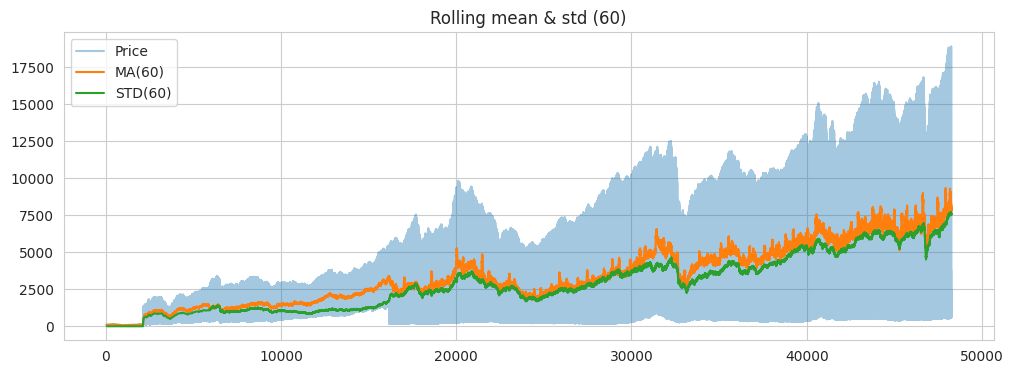

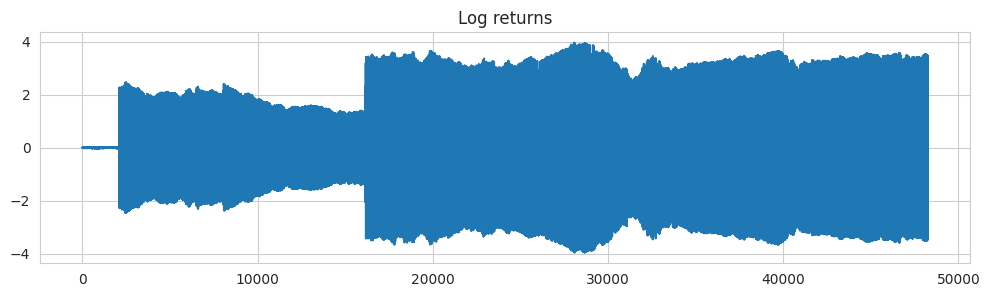

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df[price_col].values, linewidth=1)
plt.title(f'{price_col} - Time series')
plt.xlabel('Time index')
plt.ylabel(price_col)
plt.show()

plt.figure(figsize=(12,4))
rolling = df[price_col].rolling(window=60)
plt.plot(df[price_col].values, alpha=0.4, label='Price')
plt.plot(rolling.mean().values, label='MA(60)')
plt.plot(rolling.std().values, label='STD(60)')
plt.legend(); plt.title('Rolling mean & std (60)'); plt.show()

# log returns
df['log_return'] = np.log(df[price_col]).diff()
plt.figure(figsize=(12,3))
plt.plot(df['log_return'].values); plt.title('Log returns'); plt.show()

## 4) Prepare data: scaling and sequences

We will create sequences for MLP and LSTM. For ARIMA we'll use the original series (unscaled) or log-returns.

In [ ]:
# Scaling for neural models
scaler = MinMaxScaler(feature_range=(0,1))
series = df[price_col].values.reshape(-1,1)
series_scaled = scaler.fit_transform(series)

SEQ_LEN = 60

def create_sequences(data, seq_len=SEQ_LEN):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X, y = create_sequences(series_scaled, SEQ_LEN)
print('Sequences created:', X.shape, y.shape)

# Train/val/test splits (time-based)
n = len(X)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print('Train/Val/Test counts:', len(X_train), len(X_val), len(X_test))

Sequences created: (48196, 60, 1) (48196, 1)
Train/Val/Test counts: 38556 4820 4820


## 5) Model A — ARIMA (statistical baseline)

We will fit an ARIMA model on the original series (optionally on log-returns). This requires `statsmodels`.

In [ ]:
# ARIMA model (statsmodels)
try:
    import statsmodels.api as sm
    from statsmodels.tsa.arima.model import ARIMA
except Exception as e:
    raise ImportError('statsmodels is required for ARIMA. Install it with pip install statsmodels') from e

# Use log returns for stationarity (drop NaNs)
series_lr = df[price_col].apply(np.log).diff().dropna()
# Fit ARIMA: we'll try a small (p,d,q) like (5,1,0) as baseline
p, d, q = 5, 1, 0
arima_model = ARIMA(series_lr, order=(p,d,q)).fit()
print(arima_model.summary())

# Forecast on test span length
n_test = len(X_test)
start = len(series_lr) - n_test
end = len(series_lr) - 1
arima_pred_lr = arima_model.predict(start=start, end=end)
# convert log-return predictions back to price predictions by cumulative product
last_known_price = series[len(series)-n_test-1][0]
arima_prices = [last_known_price * np.exp(arima_pred_lr.iloc[0])]
for val in arima_pred_lr.iloc[1:]:
    arima_prices.append(arima_prices[-1] * np.exp(val))
arima_prices = np.array(arima_prices).reshape(-1,1)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:               CloseUSD   No. Observations:                48255
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -86862.072
Date:                Fri, 07 Nov 2025   AIC                         173736.144
Time:                        08:30:36   BIC                         173788.850
Sample:                             0   HQIC                        173752.681
                              - 48255                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.5298      0.004   -342.405      0.000      -1.539      -1.521
ar.L2         -1.5992      0.007   -220.102      0.000      -1.613      -1.585
ar.L3         -1.3284      0.008   -162.342      0.0

## 6) Model B — Dense (MLP) baseline

Train a simple fully-connected neural network on flattened windows (non-sequential).

In [ ]:
# Dense MLP baseline (Keras)
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, Flatten
except Exception as e:
    raise ImportError('TensorFlow is required for Dense and LSTM models. Use Colab or install tensorflow.') from e

# Flatten windows for MLP
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

mlp = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_flat.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
mlp.compile(optimizer='adam', loss='mse', metrics=['mae'])
mlp.summary()

history_mlp = mlp.fit(X_train_flat, y_train, validation_data=(X_val_flat, y_val),
                      epochs=30, batch_size=32, verbose=2)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,129 (63.00 KB)

 Trainable params: 16,129 (63.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1205/1205 - 5s - 4ms/step - loss: 0.0182 - mae: 0.1041 - val_loss: 0.0739 - val_mae: 0.2496
Epoch 2/30
1205/1205 - 3s - 3ms/step - loss: 0.0168 - mae: 0.0998 - val_loss: 0.0739 - val_mae: 0.2415
Epoch 3/30
1205/1205 - 4s - 3ms/step - loss: 0.0165 - mae: 0.0985 - val_loss: 0.0720 - val_mae: 0.2449
Epoch 4/30
1205/1205 - 5s - 4ms/step - loss: 0.0163 - mae: 0.0979 - val_loss: 0.0738 - val_mae: 0.2413
Epoch 5/30
1205/1205 - 3s - 3ms/step - loss: 0.0162 - mae: 0.0976 - val_loss: 0.0732 - val_mae: 0.2394
Epoch 6/30
1205/1205 - 3s - 3ms/step - loss: 0.0160 - mae: 0.0969 - val_loss: 0.0724 - val_mae: 0.2423
Epoch 7/30
1205/1205 - 4s - 3ms/step - loss: 0.0159 - mae: 0.0963 - val_loss: 0.0735 - val_mae: 0.2439
Epoch 8/30
1205/1205 - 3s - 3ms/step - loss: 0.0158 - mae: 0.0958 - val_loss: 0.0728 - val_mae: 0.2429
Epoch 9/30
1205/1205 - 3s - 3ms/step - loss: 0.0156 - mae: 0.0948 - val_loss: 0.0735 - val_mae: 0.2430
Epoch 10/30
1205/1205 - 4s - 3ms/step - loss: 0.0155 - mae: 0.0944 - val_

## 7) Model C — LSTM (sequence-based deep model)

Train a Bidirectional LSTM model on the sequences.

In [7]:
# LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout

lstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm.summary()

history_lstm = lstm.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=50, batch_size=32, verbose=2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,065 (297.13 KB)

 Trainable params: 76,065 (297.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1205/1205 - 128s - 106ms/step - loss: 0.0170 - mae: 0.1012 - val_loss: 0.0774 - val_mae: 0.2342
Epoch 2/50
1205/1205 - 139s - 115ms/step - loss: 0.0162 - mae: 0.0981 - val_loss: 0.0783 - val_mae: 0.2398
Epoch 3/50
1205/1205 - 118s - 98ms/step - loss: 0.0161 - mae: 0.0978 - val_loss: 0.0707 - val_mae: 0.2399
Epoch 4/50
1205/1205 - 117s - 97ms/step - loss: 0.0161 - mae: 0.0976 - val_loss: 0.0733 - val_mae: 0.2389
Epoch 5/50
1205/1205 - 141s - 117ms/step - loss: 0.0160 - mae: 0.0971 - val_loss: 0.0763 - val_mae: 0.2474
Epoch 6/50
1205/1205 - 116s - 97ms/step - loss: 0.0160 - mae: 0.0971 - val_loss: 0.0715 - val_mae: 0.2390
Epoch 7/50
1205/1205 - 116s - 97ms/step - loss: 0.0159 - mae: 0.0964 - val_loss: 0.0746 - val_mae: 0.2392
Epoch 8/50
1205/1205 - 142s - 118ms/step - loss: 0.0157 - mae: 0.0958 - val_loss: 0.0751 - val_mae: 0.2326
Epoch 9/50
1205/1205 - 143s - 119ms/step - loss: 0.0157 - mae: 0.0955 - val_loss: 0.0729 - val_mae: 0.2360
Epoch 10/50
1205/1205 - 143s - 119ms/step

## 8) Evaluate & Compare Models

We'll generate predictions from ARIMA, MLP, and LSTM and compare RMSE/MAE and plot results.

In [8]:
# Predict MLP and LSTM on test set
mlp_pred_scaled = mlp.predict(X_test_flat)
lstm_pred_scaled = lstm.predict(X_test)

# Inverse transform to original price scale
mlp_pred = scaler.inverse_transform(mlp_pred_scaled.reshape(-1,1))
lstm_pred = scaler.inverse_transform(lstm_pred_scaled.reshape(-1,1))
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

# ARIMA prices computed earlier as arima_prices (align lengths)
min_len = min(len(y_test_real), len(mlp_pred), len(lstm_pred), len(arima_prices))
mlp_pred = mlp_pred[-min_len:]; lstm_pred = lstm_pred[-min_len:]
y_test_real = y_test_real[-min_len:]; arima_arr = arima_prices[-min_len:]

# Compute metrics
def metrics(true, pred):
    rmse = math.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)
    return rmse, mae, r2

metrics_mlp = metrics(y_test_real, mlp_pred)
metrics_lstm = metrics(y_test_real, lstm_pred)
metrics_arima = metrics(y_test_real, arima_arr)

import pandas as pd
comp_df = pd.DataFrame({
    'Model': ['ARIMA', 'MLP', 'LSTM'],
    'RMSE': [metrics_arima[0], metrics_mlp[0], metrics_lstm[0]],
    'MAE': [metrics_arima[1], metrics_mlp[1], metrics_lstm[1]],
    'R2': [metrics_arima[2], metrics_mlp[2], metrics_lstm[2]]
})
display(comp_df)

151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
151/151 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step


,Model,RMSE,MAE,R2
0,ARIMA,8810.569021,6392.541803,-0.974585
1,MLP,7196.579264,6015.286936,-0.317408
2,LSTM,6070.277888,5087.571024,0.062686


from matplotlib import pyplot as plt
comp_df['RMSE'].plot(kind='hist', bins=20, title='RMSE')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
comp_df['MAE'].plot(kind='hist', bins=20, title='MAE')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
comp_df['R2'].plot(kind='hist', bins=20, title='R2')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
comp_df['MAE'].plot(kind='line', figsize=(8, 4), title='MAE')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
comp_df['R2'].plot(kind='line', figsize=(8, 4), title='R2')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(comp_df['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(comp_df, x='RMSE', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(comp_df['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(comp_df, x='MAE', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(comp_df['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(comp_df, x='R2', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

## 9) Plot comparison

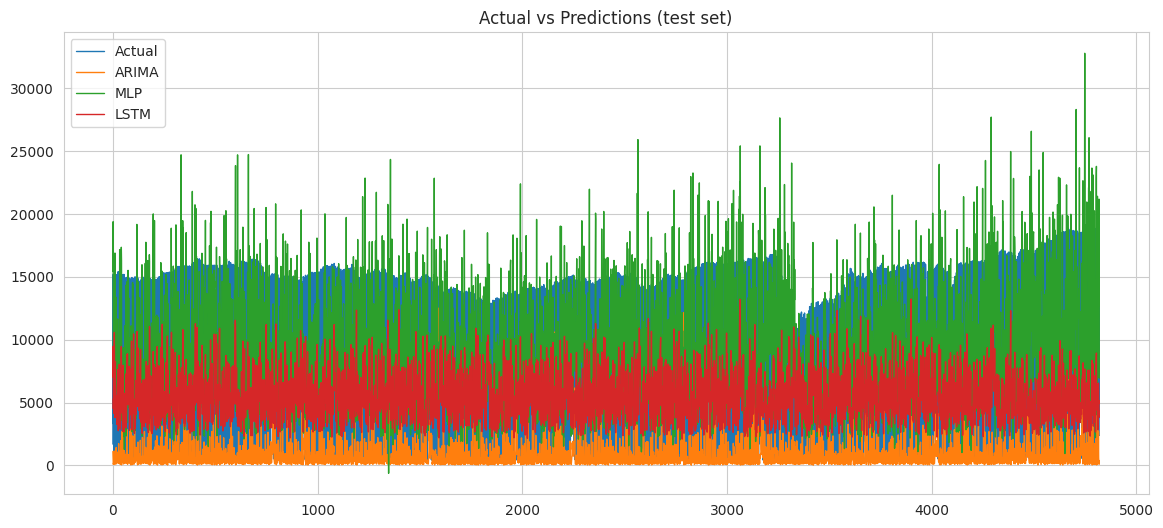

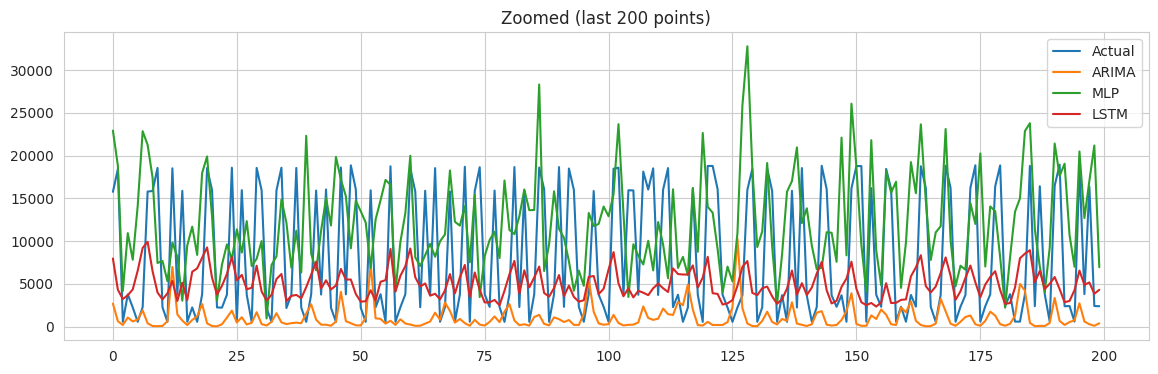

In [9]:
plt.figure(figsize=(14,6))
plt.plot(y_test_real, label='Actual', linewidth=1)
plt.plot(arima_arr, label='ARIMA', linewidth=1)
plt.plot(mlp_pred, label='MLP', linewidth=1)
plt.plot(lstm_pred, label='LSTM', linewidth=1)
plt.legend(); plt.title('Actual vs Predictions (test set)'); plt.show()

# Zoom last 200 points
zoom = 200 if len(y_test_real)>200 else len(y_test_real)
plt.figure(figsize=(14,4))
plt.plot(y_test_real[-zoom:], label='Actual')
plt.plot(arima_arr[-zoom:], label='ARIMA')
plt.plot(mlp_pred[-zoom:], label='MLP')
plt.plot(lstm_pred[-zoom:], label='LSTM')
plt.legend(); plt.title('Zoomed (last {} points)'.format(zoom)); plt.show()

## 10) Save models & summary

Save trained models and a short summary file with metrics.

In [10]:
# Save Keras models and scaler
try:
    lstm.save('/mnt/data/deepstock_lstm_model.h5')
    mlp.save('/mnt/data/deepstock_mlp_model.h5')
    import joblib
    joblib.dump(scaler, '/mnt/data/deepstock_scaler.joblib')
    print('Saved models and scaler to /mnt/data/')
except Exception as e:
    print('Error saving models:', e)

# Save comparison table
comp_df.to_csv('/mnt/data/deepstock_model_comparison.csv', index=False)
print('Saved comparison CSV to /mnt/data/deepstock_model_comparison.csv')

Saved models and scaler to /mnt/data/
Saved comparison CSV to /mnt/data/deepstock_model_comparison.csv


### Notes & next steps

- For reproducible experiments, consider adding hyperparameter search (GridSearchCV, RandomizedSearch, or Keras Tuner).
- Add technical indicators (SMA, EMA, RSI, MACD) as additional features to improve performance.
- Use walk-forward cross-validation for more robust time-series evaluation.
- Run LSTM training in a GPU runtime (Colab) to speed up training.
